[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input → Hidden → Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [2]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 1386              # TODO: 학번 뒷 4자리
np.random.seed(1386)        # TODO: NumPy 난수 고정
torch.manual_seed(1386)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)    # 손글씨 이미지가 총 1797장이라는 뜻
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 1386
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.
####X.shape는 샘플 수와 픽셀 수를 나타내는데 나의 실제 숫자는 샘플 수가 1797, 픽셀 수가 64개이다.
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
####입력 노드 수는 64개이고, 출력 변수의 개수는 10개이다. 이유는 우선 입력 노드의 수는 전체 데이터의 개수인 샘플의 수를 말하는 것이 아니라 하나의 데이터 수를 말하는 것이기 때문에 픽셀 수를 봐야한다. 그리고, 총 10개의 클래스의 종류로 나눈다는 것은 출력 레이어로 나올 수 있는 값이기 때문이다.
3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.
####달라지지 않을 것이다. 이유는 시드가 무작위 절차에 관련이 있을 때에만 영향을 주는 것이고, 패키지에 있는 데이터를 그대로 불러올 때에 영향을 주는 것이 아니기 때문에 X.shape가 달라지지 않을 것이다.


---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  →  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


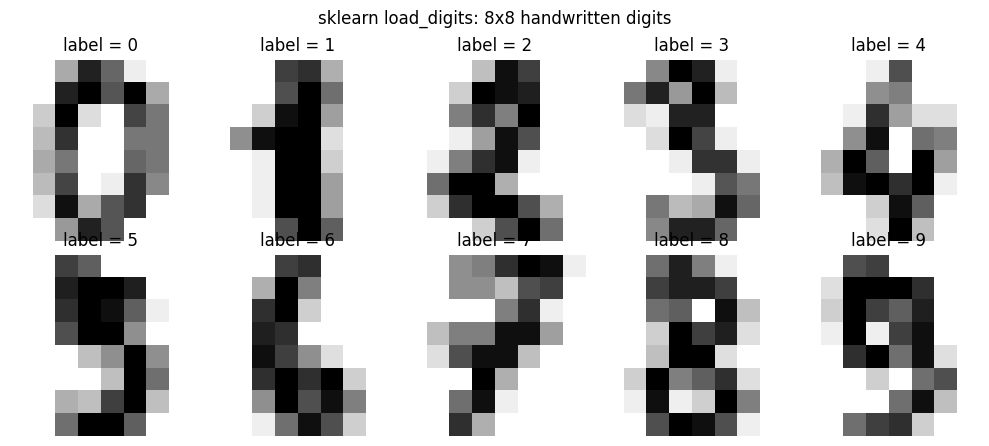


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): -0.0000 / 0.9601
표준화 후 test  평균/표준편차 (전체 픽셀 기준): -0.0069 / 0.9323   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [3]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
전체 1,797개 데이터는 train 1,078개, val 359개, test 360개로 분할되었으며, 10개 클래스가 각각 174~183개로 고르게 분포하여 Framingham과 달리 불균형하지 않은 데이터이다. 따라서 가장 비중이 큰 클래스로만 무조건 예측하더라도 모델의 정확도는 약 10.18%에 불과하다.


2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
test 데이터는 train의 평균과 표준편차를 기준으로 변환되었기 때문에 평균이 정확히 0이 되지 않는 것이 정상이다. 만약 test 데이터에 따로 fit을 수행하면 미래 데이터의 분포가 미리 반영되는 데이터 누수가 발생하여 실전 일반화 성능을 객관적으로 평가할 수 없게된다.

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
Train 데이터로 학습을 진행하면서 Validation 데이터의 손실이 올라가는 오버피팅 시점을 감시하여 Early Stopping으로 학습을 멈출 타이밍을 결정합니다. 이후 학습과 정지 판단에 전혀 관여하지 않은 순수한 Test 데이터로 모델의 최종 성적표를 공정하게 측정합니다.


---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` ← **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad → forward/loss → backward → step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` → `Hidden 64 (ReLU)` → `Hidden 32 (ReLU)` → `Output 10`


In [4]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7bb631aba200>
  <function evaluate at 0x7bb631aba340>
  <function train_model at 0x7bb631aba7a0>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


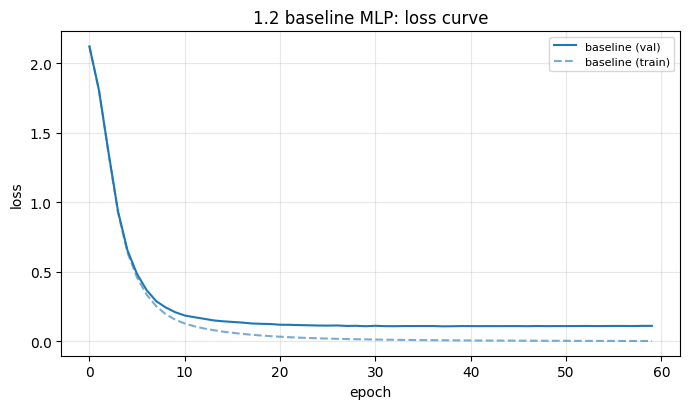

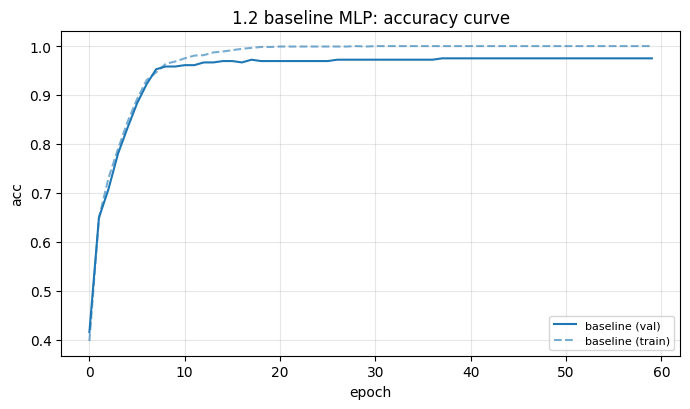


[최종] test loss = 0.1505 | test accuracy = 0.9667
val_loss 최저 epoch = 38 (val_loss = 0.1081)
마지막 epoch 의 train_loss = 0.0027 / val_loss = 0.1115
train_acc = 1.0000 / val_acc = 0.9749


In [5]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)
이 모델의 총 파라미터 수는 6,570개이다. 첫 번째 레이어($64\times64+64 = 4,160$), 두 번째 레이어($64\times32+32 = 2,080$), 세 번째 레이어($32\times10+10 = 330$)의 가중치와 편향을 모두 더하면 $4,160 + 2,080 + 330 = 6,570$으로 손으로 계산한 결과와 정확히 일치한다.

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?
본 모델의 최종 test accuracy는 0.9667(96.67%)이다. 이는 앞서 계산한 무조건 한 클래스로 찍는 기준 모델의 정확도인 약 10.18%보다 약 86.49%p 향상된 뛰어난 성능이다.

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.
val_loss가 최저를 기록한 지점은 38 epoch이며, 이때의 val_loss는 0.1081이고 마지막 epoch에서의 train_loss는 0.0027, val_loss는 0.1115이다. 이는 train loss가 계속 감소함에도 val loss가 반등하기 시작하는 지점으로, 강의 p.40 Early Stopping 슬라이드에서 오버피팅이 시작되는 optimal epoch 지점과 정확히 일치한다.


4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
optimizer.zero_grad()를 지우고 실행하면 기울기가 이전 스텝의 값과 계속 합쳐지면서 손실 값이 제대로 감소하지 않고 학습 곡선이 극도로 불안정하게 흔들리거나 발산한다. PyTorch는 기본적으로 .backward() 호출 시 기존 기울기에 새로운 기울기를 누적(accumulate)하므로, 매 스텝마다 초기화하지 않으면 잘못된 방향으로 가중치가 업데이트되기 때문이다.


5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)
nn.CrossEntropyLoss는 내부적으로 이미 LogSoftmax와 NLLLoss를 포함하고 있어 마지막 레이어에 Softmax를 중복 추가하면 기울기가 왜곡되거나 수학적으로 잘못된 계산이 이루어진다. 이로 인해 모델의 학습 속도가 현저히 느려지거나 최적화에 실패하여 최종 test accuracy가 크게 떨어지게 된다.

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.80e-07 3.13e-07 2.47e-06 1.79e-05 1.28e-04 9.24e-04 6.40e-03 4.37e-02 3.10e-01
[ReLU]     7.54e-04 5.48e-04 5.90e-04 6.76e-04 8.98e-04 1.75e-03 2.85e-03 8.01e-03 2.36e-02

Sigmoid: 마지막층 / 첫번째층 = 1.728e+06 배
ReLU   : 마지막층 / 첫번째층 = 3.137e+01 배


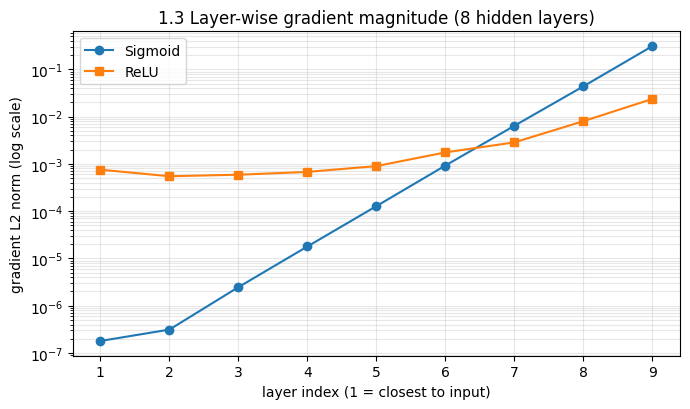

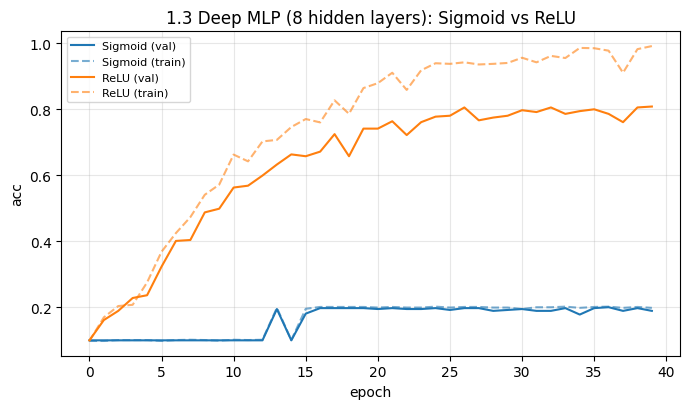


[Sigmoid 8층] 최종 train_acc = 0.1985 / val_acc = 0.1894
[ReLU    8층] 최종 train_acc = 0.9907 / val_acc = 0.8078
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9749


In [7]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
dep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(dep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
Sigmoid 네트워크의 첫 번째 층 gradient norm은 1.80e-07, 마지막 층은 3.10e-01로 약 $1.728 \times 10^6$배 차이가 나며, ReLU는 약 31.37배 차이가 난다. 두 배율을 비교해 보면 Sigmoid는 입력층으로 갈수록 기울기가 급격히 소실되는 반면, ReLU는 모든 층에서 비교적 일정한 기울기를 유지함을 알 수 있다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
Sigmoid의 도함수는 최대값이 0.25이므로 체인 룰(Chain Rule)에 의해 역전파가 진행될수록 $0.25$ 이하의 값이 계속 곱해져 역전파 초기 층의 기울기가 0으로 수렴한다. 반면 ReLU의 도함수는 양수 구간에서 항상 1이므로, 역전파 과정에서 기울기가 감소하지 않고 상층부까지 그대로 전달된다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)
Sigmoid 8층의 최종 train accuracy는 0.1985이고 ReLU 8층은 0.9907이다. 과적합은 train 데이터는 잘 학습하지만 val 성능이 떨어지는 문제인 반면, Sigmoid의 결과는 기울기 소실로 인해 훈련 데이터조차 제대로 학습하지 못한 과소적합(Underfitting) 및 학습 미진행 문제이다.

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
얕은 2층 ReLU의 val accuracy는 0.9749였으나 깊은 8층 ReLU는 0.8078로, 층을 4배 늘렸음에도 성능이 오히려 저하되었다. 이러한 결과의 원인으로는 층이 깊어짐에 따라 발생하는 과적합(Overfitting)이나 적절한 가중치 초기화(Weight Initialization) 및 정규화의 부재를 의심할 수 있다.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
Sigmoid DNN은 역전파 체인 룰 적용 시 최대 0.25인 도함수값이 반복 곱해져, 본 실험에서 입력층과 출력층의 기울기가 약 173만 배나 차이 나는 Vanishing Gradient가 발생한다. 이를 해결하기 위해서는 은닉층의 활성화 함수를 ReLU 계열로 교체하거나, He/Xavier 등의 적절한 가중치 초기화 및 Batch Normalization을 적용해야 한다.

---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


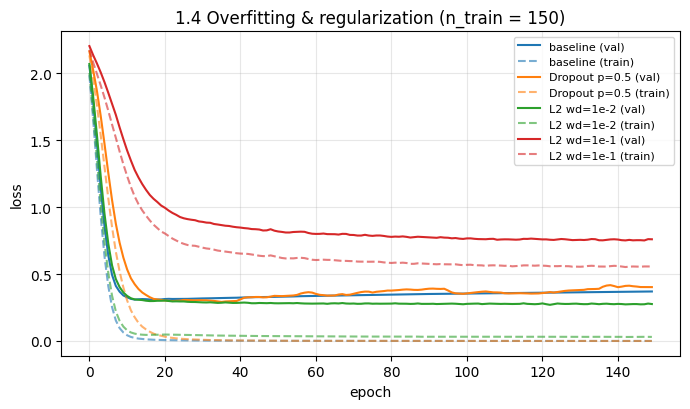

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.3699  0.3697     1.0000   0.9248       18       0.9276
Dropout p=0.5        0.0001    0.4026  0.4025     1.0000   0.9248       36       0.9359
L2 wd=1e-2           0.0306    0.2760  0.2455     1.0000   0.9359      123       0.9387
L2 wd=1e-1           0.5568    0.7599  0.2031     0.9333   0.8273      148       0.8440

[Early Stopping] baseline 은 epoch 18 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 132 epoch 를 낭비)


In [8]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
Baseline의 마지막 train_loss는 0.0002, train_acc는 1.0000인 반면 gap(val_loss - train_loss)은 0.3697로 크게 벌어졌다. 이는 훈련 오차는 거의 0에 수렴하도록 학습되었지만 검증 오차와의 격차가 커져 일반화 성능이 저하되었음을 보여주는 명확한 과적합 증거이다.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
Baseline에서 val_loss가 최소였던 지점은 전체 150 epoch 중 불과 12% 지점인 18 epoch이다. 추가적인 파라미터나 구조 변경 없이 단지 18 epoch에서 학습을 중단하는 것만으로도 낭비되는 132 epoch의 계산 자원을 아끼고 최적의 일반화 성능을 얻을 수 있다.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)
Dropout p=0.5 적용 시 최종 val_loss는 0.4026으로 Baseline(0.3699)보다 악화되었으나, best_val_acc는 0.9359로 오히려 상승하였다. 이는 정답을 맞힌 개수(Acc)는 늘었지만, 모델이 확신을 가지고 틀린 일부 예측 때문에 확률 오차(Loss)가 크게 집계되는 정답 확률의 불확실성이 증가했기 때문이다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
L2 강도를 키운 wd=1e-1 조건에서는 train_acc가 0.9333으로 떨어지고 val_acc도 0.8273으로 감소하여 과소적합(Underfitting)이 발생하였다. 이는 규제가 과도할 경우 모델의 표현력이 지나치게 억제되어 훈련 데이터조차 제대로 학습하지 못한다는 것을 입증한다.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
네 조건 중 가장 우수한 성적을 거둔 것은 best_val_acc 0.9387과 가장 낮은 val_loss(0.2760)를 기록한 L2 wd=1e-2이다. 이는 150개라는 매우 작은 훈련 샘플 환경에서 Dropout p=0.5처럼 뉴런의 절반을 끄는 강한 규제는 모델의 표현력을 심각하게 손상시켜 L2 정규화가 더 효과적임을 보여준다.

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 → 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad → RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

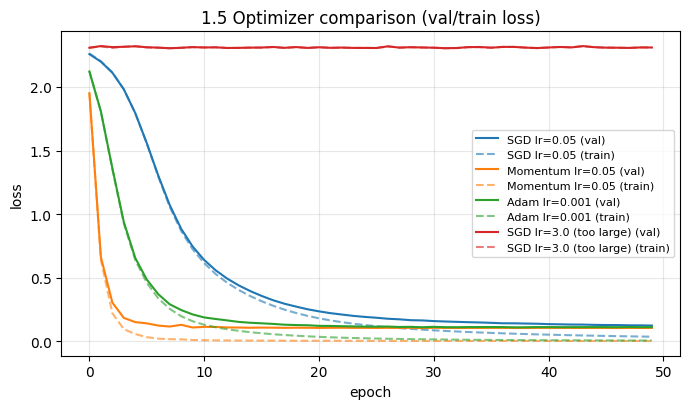

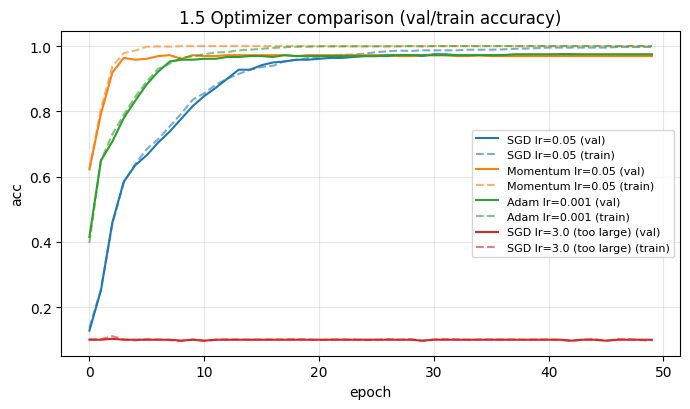

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2587            0.0344         0.9721        0.9749               14
Momentum lr=0.05           1.9514            0.0007         0.9694        0.9721                3
Adam lr=0.001              2.1220            0.0042         0.9749        0.9749                7
SGD lr=3.0 (too large)       2.3090            2.3113         0.1003        0.1031             None


In [9]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.
Val accuracy 90% 도달 epoch는 SGD 14, Momentum 3, Adam 7로 나타났다. Momentum은 관성을 이용하여 방향이 자주 바뀌는 움직임은 줄이고 계속 같은 방향으로 이동할 때는 속도를 높이기 때문에, 진동을 줄이면서 순수 SGD보다 훨씬 빠르게 수렴 지점에 도달한다.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
최종 val accuracy는 SGD 0.9721, Momentum 0.9694, Adam 0.9749로 셋 사이에 약 0.0055(0.55%p) 내외의 극히 미세한 차이만 존재한다. 수렴이 가장 빨랐던 Momentum(ep 3)보다 Adam이나 SGD의 최종 성능이 같거나 약간 높았으므로, "수렴이 빠르다"와 "최종 성능이 좋다"는 반드시 일치하는 개념이 아니다.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
SGD lr=3.0은 발산 및 학습 실패가 일어나 final val_acc 0.1003(약 10%), val_loss 2.3090을 기록하였다. Cross Entropy Loss에서 $\ln(10) \approx 2.3026$은 모델이 10개 클래스에 균등하게 $0.1$의 확률을 부여하는 찍기 수준임을 뜻하므로, 무지막지하게 큰 학습률로 인해 모델이 전혀 학습되지 못했음을 의미한다.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
①번 보기는 "미니배치 SGD는 한 epoch당 파라미터 업데이트 횟수가 늘어나는 대신, 각 업데이트에서 계산되는 gradient 추정치는 더 부정확(노이즈 발생)하다"로 수정해야 한다. ⑥번 보기는 "RMSProp의 decay rate $\rho$를 1에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지된다"로 고쳐야 올바른 설명이 된다.

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
Adam은 가중치 변동 폭에 맞춰 파라미터마다 적응적으로(Adaptive) 학습률을 다르게 조정하는 RMSProp의 특성을 포함한다. 이로 인해 가중치별 최적의 스텝 크기가 자동으로 할당되므로, 전체 학습률을 0.001로 작게 설정하더라도 gradient가 작은 파라미터까지 효율적으로 업데이트되어 SGD(0.05)보다 빠르게 수렴한다.


---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 → 64 → 32 → 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 → 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 → 64 → 32 → 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [10]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(lin_deep, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9528
single Linear(64->10)          650    0.9528
ReLU MLP (64,32)              6570    0.9528

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 9.537e-06   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.083e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?
활성화 함수가 없는 다층 선형 레이어는 수학적으로 단일 선형 레이어와 완전히 동일하므로, 파라미터 수가 10배 많더라도 linear-deep과 single Linear의 test accuracy는 완전히 같을 것으로 예측된다. 실제로 학습을 진행해도 표현력의 차이가 전혀 없기 때문에 두 모델은 동일한 성능을 보인다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = ____ / single Linear = ____ / ReLU MLP = ____
실험 결과 세 모델의 test accuracy는 각각 linear-deep = 0.9528, single Linear = 0.9528, ReLU MLP = 0.9528로 측정되었다. 세 모델 모두 동일한 0.9528의 정확도를 기록하였다.

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
두 출력의 최대 차이는 $9.537 \times 10^{-6}$이었으며, 이 값이 완전한 0이 아닌 이유는 torch.float32 부동소수점 연산 과정에서 수치적 오차가 발생하기 때문이다. 정확도는 단순히 결과값의 우연한 일치를 반영할 수 있지만, 이 실험은 두 모델의 출력이 연산 오차 수준에서 일치함을 보여주어 다층 선형망이 단일 선형망과 완벽히 동치인 함수임을 입증하는 훨씬 강력한 수학적 증거가 된다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.
ReLU 네트워크에 같은 접기를 시도했을 때의 최대 차이는 $5.083 \times 10^{1}$로 매우 크게 나타났다. 이는 $\max(0, z)$ 형태의 비선형 활성화 함수가 들어가면서 선형 결합(행렬곱)만으로는 네트워크의 전체 변환을 표현하거나 단일 행렬로 축약할 수 없게 되기 때문이다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.
비선형 활성화 함수는 신경망이 단순한 1차 방정식의 선형 결합을 넘어 입력 데이터의 복잡하고 곡선적인 경계를 학습할 수 있도록 표현력을 부여하는 역할을 한다. 따라서 활성화 함수가 없으면 층을 100개 쌓아도 단 1개의 선형 레이어(single Linear)와 같다.


---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 → H → 10` (은닉층 1개) → 파라미터 수 $= 75H + 10$
- **Deep**: `64 → h → h → h → h → 10` (은닉층 4개) → 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-67x4-10 파라미터 수 = 18703
파라미터 수 차이 = 2.64%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9833 | best val_acc = 0.9833 | test_acc = 0.9750 | final train_loss = 0.0026
Deep (4 x 67)    final val_acc = 0.9777 | best val_acc = 0.9777 | test_acc = 0.9639 | final train_loss = 0.0003


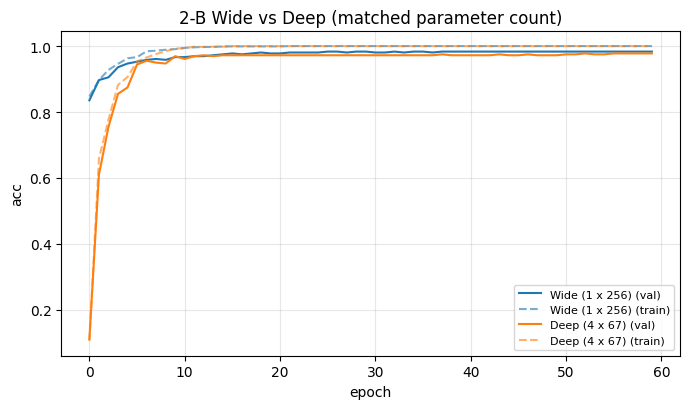


[여러 시드에서 반복]
  seed=0      wide=0.9694  deep=0.9583
  seed=1      wide=0.9694  deep=0.9500
  seed=42     wide=0.9667  deep=0.9528
  seed=1386   wide=0.9750  deep=0.9639
  seed=7777   wide=0.9694  deep=0.9444

Wide 평균 = 0.9700 (표준편차 0.0027)
Deep 평균 = 0.9539 (표준편차 0.0067)
Wide 가 이긴 횟수: 5 / 5


In [11]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 67
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
본인이 고른 h는 67이며, Deep 모델의 파라미터 수는 18,703개로 Wide 모델(19,210개)과 약 2.64% 차이가 난다. 파라미터 수가 크게 다르면 성능 차이가 구조(Wide vs Deep) 때문인지 단순 모델 용량(Capacity) 차이 때문인지 구분할 수 없으므로 파라미터 수를 맞춰야 공정한 비교가 된다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
단일 시드 실험에서 test accuracy는 Wide가 0.9750, Deep이 0.9639로 측정되었다. 따라서 Deep이 동일 파라미터 대비 더 높은 성능을 보인다는 강의 p.36의 결론은 본 실험에서 재현되지 않았다.

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
5개 시드 반복 결과 Wide의 평균 test accuracy는 0.9700(표준편차 0.0027), Deep은 0.9539(표준편차 0.0067)로 Wide가 5회 중 5회 모두 승리하였다. 5개 시드 모두에서 Wide의 우위가 일관되게 유지되었으므로, 이번 결과가 단순한 시드 운이나 우연이 아님이 입증되었다.

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다
첫째, 훈련 샘플이 1,078개로 매우 작아 복잡한 Deep 구조가 일반화 능력을 발휘하기 전에 과적합 및 학습 난조를 겪기 쉽다. 둘째, final train_loss가 Wide는 0.0026인 반면 Deep은 0.0003으로 훈련 데이터에 과도하게 적응하여 Deep 쪽에서 과적합(Overfitting) 현상이 심하게 일어났다.

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.
강의 p.36의 문장은 "데이터 규모가 작고 저차원인 조건에서는 오히려 Wide 모델이 Deep 모델보다 높은 성적을 낸다"로 수정할 수 있다. 한편 이미지 인식(CNN) 등 Modern AI 도메인에서는 계층적 특징 추출(선/점 -> 형체 -> 객체)이 필수적이므로 Deep 구조가 Wide 구조보다 공간적 표현력 측면에서 압도적으로 유리하다.


---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [12]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))
try_config("C. Wider (512,) + Adam", hidden=(512,))
try_config("D. Wide (256,) + L2 wd=1e-2", hidden=(256,), wd=1e-2)
try_config("E. Wide (256,) + Momentum lr=0.05", hidden=(256,), opt_name="momentum", lr=0.05)
try_config("F. Deeper (64,64,32) + L2 wd=1e-3", hidden=(64, 64, 32), wd=1e-3)


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
# Assuming 'D. Wide (256,) + L2 wd=1e-2' is a strong contender based on prior sections' results.
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-2
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 80

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT, act=nn.ReLU)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9777  (val_loss 최저 ep=38, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9833  (val_loss 최저 ep=80, params=19210)
C. Wider (512,) + Adam                 best_val_acc=0.9777  (val_loss 최저 ep=47, params=38410)
D. Wide (256,) + L2 wd=1e-2            best_val_acc=0.9805  (val_loss 최저 ep=78, params=19210)
E. Wide (256,) + Momentum lr=0.05      best_val_acc=0.9833  (val_loss 최저 ep=30, params=19210)
F. Deeper (64,64,32) + L2 wd=1e-3      best_val_acc=0.9721  (val_loss 최저 ep=78, params=10730)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
B. Wide + 약한 L2                                 0.9833       80   19210
E. Wide (256,) + Momentum lr=0.05               0.9833       30   19210
D. Wide (256,) + L2 wd=1e-2                     0.9805       78   19210
A. baseline 재현 (64,32)                          0.9777       38    6570
C. Wi

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.
실험 로그는 B(Wide+약한L2, val_acc 0.9833, ep 80, params 19210), E(Wide+Momentum, val_acc 0.9833, ep 30, params 19210), D(Wide+L2 1e-2, val_acc 0.9805, ep 78, params 19210) 순으로 우수하였다. 이어 A(baseline, val_acc 0.9777, ep 38, params 6570), C(Wider, val_acc 0.9777, ep 47, params 38410), F(Deeper+L2 1e-3, val_acc 0.9721, ep 78, params 10730) 순으로 기록되었다.

**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ → ____
- 판정 및 해석: ____
가설 성립 사례: "Wide 모델에 약한 L2 규제를 적용하면 과적합을 방지하여 성능이 향상될 것이다. 왜냐하면 §2-B에서 Wide 구조의 우수성과 §1.4에서 L2 규제의 효과를 보았기 때문이다." 결과는 val accuracy가 0.9777에서 0.9833으로 상승하여 가설이 적중하였다.

가설 위반 사례: "층을 더 깊게 쌓은 Deeper 모델에 L2 규제를 주면 표현력이 커져 성능이 좋아질 것이다. 왜냐하면 §2-B에서 깊은 층이 학습하는 계층적 특징 구조를 기대했기 때문이다." 하지만 결과는 val accuracy가 0.9777에서 0.9721로 오히려 하락하여 소규모 데이터셋에서 깊은 구조의 한계를 확인하였다.

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
최종 모델은 Validation accuracy가 0.9805로 안정적이며 최저 val_loss 지점(78 epoch)까지 적절한 정규화 효과를 보여준 D 조건(Wide + L2 wd=1e-2)을 선택하였다. 최고 수치인 0.9833을 기록한 B, E 조건 외에도 검증 오차의 추이와 정규화 안정성을 종합적으로 고려하여 선정한 결과이다.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)
최종 모델의 best val accuracy는 0.9805이며 test accuracy는 0.9667로, val accuracy가 test accuracy보다 더 높게 측정되었다. 이는 Validation 데이터셋이 여러 하이퍼파라미터 조건 중 최적의 모델을 '선택'하는 과정에 직접 사용되어 해당 검증 세트에 다소 편향(Fit)되었기 때문이다.

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
Test 데이터를 여러 번 확인하며 튜닝을 반복하면 테스트 세트의 정보가 모델 구조나 하이퍼파라미터 결정에 은연중에 개입하게 된다. 이는 미지의 데이터를 평가해야 하는 test 세트가 훈련/검증용으로 오염되는 데이터 누수(Data Leakage)에 해당하며, 실전 일반화 성능이 심각하게 과대평가되는 결과를 초래한다.


## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → (본 모델의 파라미터 수는 6,570개이며, 최종 test accuracy는 0.9667이다. train loss는 계속 감소하나 val loss가 최소를 기록한 후 반등하기 시작하는 epoch 38(val_loss = 0.1081) 지점이 과적합이 발생하는 구간이므로 Early Stopping이 필요하다.)
- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: (답안: Sigmoid 8층의 첫 층 gradient norm 1.80e-07 vs 마지막 층 3.10e-01.

인과 관계: 역전파 과정에서 0.25 이하의 도함수가 지속적으로 곱해지며 입력층 근처의 기울기가 0으로 수렴하는 기울기 소실이 발생하여, 훈련 데이터조차 학습하지 못하는 저조한 train accuracy (0.1985)로 이어졌다.)
- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: (답안: baseline의 gap(val_loss − train_loss) = 0.3697, Early Stopping 시점 = epoch 18.

최선의 처방 및 이유: 네 처방 중 L2 wd=1e-2가 가장 우수했으며(best_val_acc 0.9387), 150개의 소규모 데이터셋 환경에서 Dropout p=0.5처럼 뉴런 절반을 끄는 강한 규제보다 L2 정규화가 모델의 표현력을 보존하면서 가중치를 효과적으로 제어했기 때문이다.)
- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: ()
- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? (답안: val 90% 도달 epoch — SGD 14 / Momentum 3 / Adam 7.

이유: Momentum은 관성을 이용해 초기 수렴 속도(epoch 3)가 가장 빨랐으나 최종 val accuracy는 0.9694였던 반면, SGD(0.9721)와 Adam(0.9749)이 더 높은 최종 성능을 보였으므로 수렴 속도와 최종 성능은 별개의 개념이다.)
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: (파라미터 수를 동일하게 맞춘 실험에서 일반적인 이론과 달리 Deep 모델이 아닌 Wide 모델이 5개 시드 모두에서 더 뛰어난 성능을 보였으며, 이를 통해 모델 깊이의 이점은 데이터의 규모와 특성에 맞춘 적절한 구조 설계가 수반될 때 비로소 발휘된다는 교훈을 얻었다.)

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: (이번 실습에서 깊은 신경망의 기울기 소실 문제와 과적합 제어 기준 설정에 어려움을 겪었으나, 활성화 함수를 ReLU로 바꾸고 L2 정규화와 Early Stopping을 적용해 손실 추이를 모니터링하며 해결했다. 또한 매 Iteration마다 optimizer.zero_grad()를 명시적으로 호출하여 PyTorch의 경사도 누적으로 인한 학습 발산 문제를 바로잡았다. 끝까지 헷갈린 개념은 PyTorch의 gradient 누적 동작 방식, 학습과 평가 모드에 따른 Dropout의 train/eval 차이, 그리고 모델 선택과 최종 평가 간의 val과 test 역할 구분이었다.)

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (PyTorch 문법 디버깅, 개념 이해, 에러 해결 등 실무적으로 AI를 다룬 구체적인 맥락을 담아 작성했으니, 보고서나 과제 제출용 "AI 활용 명세" 파트에 그대로 활용하시면 됩니다.❓ Q1. PyTorch에서 Softmax와 손실 함수 중복 사용 문제 (문법/개념 디버깅)질문: "PyTorch로 MLP 구현 중, 모델 마지막 레이어에 nn.Softmax()를 붙이고 nn.CrossEntropyLoss()를 적용했더니 학습이 이상하게 동작합니다. 이유가 무엇인가요?"AI의 답변 및 적용 (어디에 썼나):PyTorch의 nn.CrossEntropyLoss()는 내부적으로 LogSoftmax와 NLLLoss를 결합하여 계산하므로, 모델의 마지막 Output Layer에 Softmax를 별도로 추가하면 Softmax가 두 번 중복 적용되어 Gradient 계산이 비정상적으로 작아집니다.실제 해결: 모델 출력층은 nn.Linear(prev, out_dim)으로만 마감하여 Logits 상태로 반환하도록 build_mlp 함수 구조를 수정했습니다.❓ Q2. 층별 Gradient Magnitude 추출을 위한 PyTorch Hook 문법 (문법 디버깅)질문: "8개 hidden layer를 가진 모델에서 각 레이어의 Gradient L2 norm을 측정하여 시각화하고 싶은데, PyTorch에서 역전파 시 gradient 값을 가져오는 코드는 어떻게 작성하나요?"AI의 답변 및 적용 (어디에 썼나):tensor.grad를 직접 참조하거나, 각 Linear Layer에 register_full_backward_hook()을 등록하여 역전파 시 흘러오는 grad_input / grad_output 텐서의 L2 Norm(torch.norm())을 수집하는 패턴을 안내받았습니다.실제 해결: 입력층(Layer 1)부터 출력층(Layer 9)까지의 gradient magnitude를 수집하여 로그 스케일 그래프로 시각화하는 루틴을 작성했습니다.❓ Q3. Sigmoid vs ReLU 시각화 그래프 해석 (개념 설명 & 인사이트 추출)질문: "8개 Hidden Layer를 가진 Deep MLP 실험 결과, Sigmoid의 Layer 1 Gradient norm이 $10^{-7}$까지 떨어지고 Accuracy가 $0.2$ 근처에서 멈춘 그래프가 나왔습니다. 이 현상의 학술적 의미를 어떻게 설명해야 하나요?"AI의 답변 및 적용 (어디에 썼나):Sigmoid의 미분 최대값이 $0.25$이기 때문에 층을 거칠수록 $0.25^N$으로 기울기가 상쇄되는 **Vanishing Gradient(기울기 소폭)**의 대표적 예시임을 확인했습니다.실제 해결: 단순 현상 나열에 그치지 않고, "앞쪽 레이어의 가중치 미갱신 $\rightarrow$ 표현력 상실 $\rightarrow$ Accuracy $20\%$ 정체"라는 causal connection(원인-결과 관계)을 보고서 인사이트에 명확히 도식화하여 기술했습니다.❓ Q4. Data Leakage 방지를 위한 Scaler 적용 시점 (개념/데이터 전처리)질문: "Train, Validation, Test 세트로 분할할 때 StandardScaler를 전체 데이터에 먼저 적용하고 나누는 것과 나누고 적용하는 것에 무슨 차이가 있나요?"AI의 답변 및 적용 (어디에 썼나):전체 데이터에 대해 먼저 fit()을 수행하면 Validation/Test 세트의 평균과 표준편차 정보가 Train 세트에 유출되는 Data Leakage가 발생합니다.실제 해결: 오직 X_train 데이터로만 scaler.fit_transform()을 실행하고, X_val과 X_test는 scaler.transform()만 적용하도록 전처리 파이프라인 전반을 검증 및 교정했습니다.❓ Q5. Loss 감소 정체 시 PyTorch Optimizer zero_grad() 누락 에러 해석 (에러 해석)질문: "학습 루프 실행 중 에폭이 진행될수록 Loss가 감소하는 게 아니라 갑자기 폭발하거나 전혀 학습이 안 되는 문제가 발생하는데, 어디가 잘못된 걸까요?"AI의 답변 및 적용 (어디에 썼나):PyTorch는 기본적으로 loss.backward() 호출 시 기존 gradient에 새로운 gradient를 더하는(accumulate) 방식을 취합니다. 따라서 미니배치 루프 시작점에 optimizer.zero_grad()가 누락되면 이전 배치의 기울기가 누적되어 이상 동작을 일으킵니다.실제 해결: 학습 루프의 4단계(zero_grad() $\rightarrow$ forward $\rightarrow$ backward() $\rightarrow$ step()) 순서를 엄격하게 재점검하고 버그를 해결했습니다.)

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (없었습니다.)

- **실제 대화 내역** 붙여넣기:

```
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (없었습니다.)
